# IEAP-python-series03: Assignment

| Student | sections | branch |
| :--- | :--- | :--- |
| THEBUWANA Vidusha | Section 2 and 3 | Section-2|
| CLANET Damien| Section 4 | Section-4 |

We decided to work on two seperate files on two seperate brnanches and combine them after merging to prevent data corruption. Incase the functions from the begining are needed in other sections, functions were added to a python file "signal_functions.py" and could be imported with the command "import signal_functions as sf".

## Vidusha - Section 2 & 3

### Section 2 - Create functions to find and plot remarkable points

#### 2.1. Functions to find zero crossings and to plot them

First we import the necessary libraries. Since there were a lot of functions, I used a signal_functions.py file with all the functions in it. However, for reporting I copy pasted the functions as code blocks. 

In [2]:
#import signal_functions as sf
import numpy as np
import matplotlib.pyplot as plt

The index and signal arrays of the provided the signal is as follows:

In [3]:
index = np.array([ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 ])
signal = np.array([ -1, 1, 2, 1, 0, -1, 1, 2, 1, -2 ])

The functions that were live coded are added from the signal_functions.py. According to the requirement of 2.2, the code is improved by adding comprehensive Doc strings, explanatory comments on lines that needed more explanations and comments for blocks that do a specific task.

In [4]:
def find_zero_crossings_no_zeros(signs: np.ndarray):
    """Find zero crossings in a sign array without zeros
    
    A crossing at index i means the sign changes between position i and
    position i + 1 (i.e., i is the last sample BEFORE the change).
 
    Parameters
    ----------
    signs : np.ndarray
        1D array of signs containing only -1 and +1 (no zeros).
 
    Returns
    -------
    i_cross_pos : np.ndarray
        Indices i where the sign goes from negative to positive
        (signs[i] = -1, signs[i + 1] = +1).
    i_cross_neg : np.ndarray
        Indices i where the sign goes from positive to negative
        (signs[i] = +1, signs[i + 1] = -1).
    
    """
    #Compute adjacent differences
    diff = np.diff(signs)
    #Find positive differences (> 0)
    i_cross_pos = np.where(diff > 0)[0]
    #Find negative differences (< 0)
    i_cross_neg = np.where(diff < 0)[0]
    #returning i_cross positive and negative values
    return i_cross_pos, i_cross_neg

def propagate_signs_over_zeros(signs: np.ndarray):
    """Propagate non-zero signs over zero positions in the sign array.
    
    Each zero takes the value of the last non-zero sign before it
    (forward fill). Leading zeros, which have no previous sign, take the
    value of the first non-zero sign in the array. If the array contains
    only zeros, it is returned unchanged (all zeros).
 
    Parameters
    ----------
    signs : np.ndarray
        1D array of signs with values in {-1, 0, +1}.
 
    Returns
    -------
    np.ndarray
        Copy of `signs` of the same length in which zeros have been
        replaced by neighbouring non-zero signs. The input is not modified.
    
    """
    #
    signs_no_zeros = signs.copy()
    mask = signs_no_zeros != 0
    idx = np.where(mask, np.arange(len(signs_no_zeros)), 0)
    idx = np.maximum.accumulate(idx)
    signs_no_zeros = signs_no_zeros[idx]
    if signs_no_zeros[0] == 0:
        i_first_nonzero = np.where(signs != 0)[0]
        if len(i_first_nonzero) > 0:
            signs_no_zeros[: i_first_nonzero[0]] = signs[i_first_nonzero[0]]
    return signs_no_zeros

def find_zero_crossings(s: np.ndarray):
    """Find zero crossings in a 1D signal array.
    
    Samples equal to zero are not treated as crossings by themselves: they
    inherit the sign of the previous non-zero sample (see
    `propagate_signs_over_zeros`), so a crossing is only reported when the
    signal actually changes sign. A crossing at index i means the sign
    changes between sample i and sample i + 1.
 
    Parameters
    ----------
    s : np.ndarray
        1D array (or array-like) of signal values.
 
    Returns
    -------
    i_pos : np.ndarray
        Indices of positive crossings (negative -> positive).
    i_neg : np.ndarray
        Indices of negative crossings (positive -> negative).
 
    Raises
    ------
    ValueError
        If `s` is not 1-dimensional.
    

    """
    # Accept lists/tuples too: asarray converts them (no copy if already an array)
    s = np.asarray(s)
    #checks if the dimensions are correct - needs to be 1D
    if s.ndim != 1:
        raise ValueError("Input must be a 1D array")
    
    # Step 1: reduce the signal to its signs
    # np.sign gives -1, 0 or +1 for each sample; only the sign matters for crossings, not the amplitude. astype(int) makes the output integer (np.sign on floats returns floats).
    signs = np.sign(s).astype(int)
    
    # Step 2: remove zeros
    # A sample that is exactly 0 has no sign, so it cannot be classified as positive or negative. Replace zeros with the neighbouring sign so that a crossing is only reported when the sign really changes. i_zeros holds the indices of zero samples; only its size is used here.
    i_zeros = np.where(signs == 0)[0]
    if i_zeros.size > 0:
        signs_no_zeros = propagate_signs_over_zeros(signs)
    else:
        # Nothing to fix, reuse the array as is
        signs_no_zeros = signs

    # Step 3: locate the sign changes   
    return find_zero_crossings_no_zeros(signs_no_zeros)

def test_find_zero_crossings():
    """Unit tests for find_zero_crossings function.
    
    Checks the returned positive/negative crossing indices on signals with
    alternating signs, zeros between signs, leading and trailing zeros, and
    signals with no real crossings. Takes no inputs and returns nothing;
    raises AssertionError if any check fails.
    
    
    """
    s = np.array([-1, 1, -1, 1, -1])
    # expected + - + - +
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([0, 2]))
    assert np.array_equal(i_neg, np.array([1, 3]))
    
    s = np.array([-1, 0, 0, 1, 0, -1])
    # expected - + -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([2]))
    assert np.array_equal(i_neg, np.array([4]))
    
    s = np.array([0, 0, 0, 1, 0, 0])
    # expected no crossings
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([]))
    
    s = np.array([0, 0, 1, 0, -1, 0])
    # expected -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([3]))
    
    s = np.array([0, 1, 0, 0, -1, 0])
    # expected -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([3]))
    
    s = np.array([1, 0, 0, -1, 0, 0])
    # expected -
    i_pos, i_neg = find_zero_crossings(s)
    assert np.array_equal(i_pos, np.array([]))
    assert np.array_equal(i_neg, np.array([2]))

# Testing the function
try:
    test_find_zero_crossings()
    print("All tests passed.")
except AssertionError:
    raise # propagate the error

def plot_signal(i: np.ndarray, s: np.ndarray, color: str = "blue"):
    """Plot the signal as function of time/index with grid and zero line
    
    Draws a gray horizontal line at y = 0 (behind the signal) and then the
    signal as small dots joined by thin lines. Also sets the axis labels.
    Does not create a new figure and does not call plt.show().
 
    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (sample indices or time stamps).
    s : np.ndarray
        1D array of signal values, same length as `i`.
    color : str, optional
        Matplotlib color of the signal line (default "blue").
 
    Returns
    -------
    None
    
    """
    #drawing a straight horizontal line across the entire width of the plot(y=0 - in the middle))
    plt.axhline(y=0, color="gray", linestyle="-") # before to be under the signal
    # Map the index array to the x-axis and the signal array to the y-axis.
    plt.plot(i, s, ".-", markersize=5, linewidth=0.25, color=color, label="signal")
    #lablelling signal and index
    plt.ylabel("signal")
    plt.xlabel("index")

def plot_remarkable_points(t: np.ndarray, s: np.ndarray, format: str, label: str):
    """Plot remarkable points on a signal with format and label
    
    Generic helper used to mark points of interest, such as zero crossings.
 
    Parameters
    ----------
    t : np.ndarray
        x-values (indices or times) of the points to mark.
    s : np.ndarray
        y-values (signal values) of the points, same length as `t`.
    format : str
        Matplotlib format string giving marker and color (e.g. "^r" for
        red up-triangles).
    label : str
        Legend label for these points.
 
    Returns
    -------
    None
    
    """
    plt.plot(t, s, format, markersize=10, label=label)

def plot_positive_zero_crossings(i: np.ndarray, s: np.ndarray, i_pos: np.ndarray):
    """Plot positive zero crossings on a signal
    
    Mark the positive zero crossings of a signal on the current figure.
 
    Positive crossings (negative -> positive) are passed in already computed
    (from `find_zero_crossings`) and drawn as red up-triangles at the sample
    just before the sign change.
 
    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.
    i_pos : np.ndarray
        Indices of positive crossings, as returned by `find_zero_crossings`.
 
    Returns
    -------
    None
    
    """
    plot_remarkable_points(i[i_pos], s[i_pos], "^r", "positive zero crossings")

def plot_negative_zero_crossings(i: np.ndarray, s: np.ndarray, i_neg: np.ndarray):
    """Plot negative zero crossings on a signal
    
    Negative crossings (positive -> negative) are passed in already computed
    (from `find_zero_crossings`) and drawn as yellow down-triangles at the
    sample just before the sign change.
 
    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.
    i_neg : np.ndarray
        Indices of negative crossings, as returned by `find_zero_crossings`.
 
    Returns
    -------
    None
    
    """
    plot_remarkable_points(i[i_neg], s[i_neg], "vy", "negative zero crossings")

def plot_zero_crossings(i: np.ndarray, s: np.ndarray):
    """Plot all zero crossings on a signal
    
    Finds the crossings once with `find_zero_crossings`, then calls
    `plot_positive_zero_crossings` and `plot_negative_zero_crossings`.
    The signal itself is not drawn.
 
    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.
 
    Returns
    -------
    None
    
    """
    i_pos, i_neg = find_zero_crossings(s)
    plot_positive_zero_crossings(i, s, i_pos)
    plot_negative_zero_crossings(i, s, i_neg)

def display_signal_and_crossings(i: np.ndarray, s: np.ndarray):
    """Plot signal and zero crossings with legend outside the plot and grid
    
    Opens a new figure, plots the signal, marks positive and negative zero
    crossings, adds a legend placed outside the axes (upper right) and a
    grid, then displays the figure.
 
    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.
 
    Returns
    -------
    None
    
    """
    plt.figure()
    plot_signal(i, s)
    plot_zero_crossings(i, s)
    # NOTE: legend outside does not work well with %matplotlib widget
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()

All tests passed.


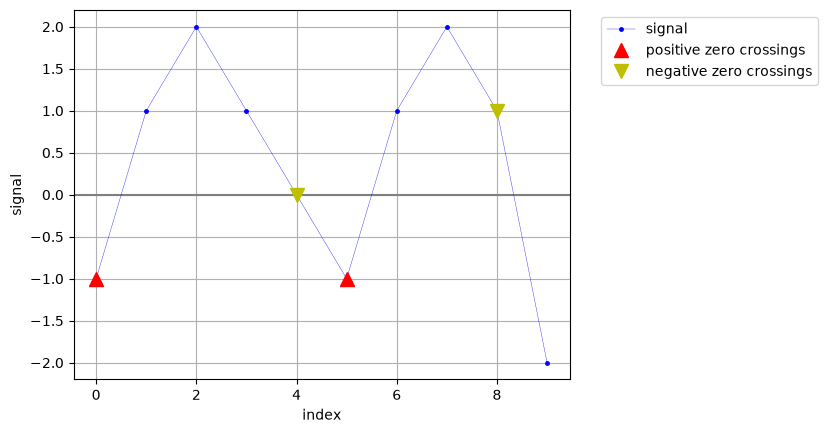

In [5]:
display_signal_and_crossings(index, signal)

### 2.2. Explain and improve the previous code

To understand the original flow of the functions, a flow chart(and pseudcode) was built for us to understand the code better.

```text
[Entry Point] display_signal_and_crossings(i, s)
│
├── 0. plt.figure()
│      └── Opens a new figure
│
├── 1. plot_signal(i, s)
│      ├── plt.axhline(y=0)  -> gray zero line (drawn first, so it sits behind the signal)
│      ├── plt.plot(i, s)    -> signal as small dots joined by thin lines
│      └── plt.ylabel / plt.xlabel -> sets the axis labels
│
├── 2. plot_positive_zero_crossings(i, s)
│      │
│      ├── Call: find_zero_crossings(s)
│      │   ├── Step A: np.asarray(s) -> accepts lists/tuples
│      │   │           └── If s.ndim != 1 -> raise ValueError
│      │   ├── Step B: np.sign(s).astype(int) -> values -1, 0, +1
│      │   ├── Step C: Are there any zeros in signs?
│      │   │   ├── YES -> propagate_signs_over_zeros(signs)
│      │   │   │          (forward-fill zeros; leading zeros take the first non-zero sign)
│      │   │   └── NO  -> use signs as is
│      │   └── Step D: find_zero_crossings_no_zeros(signs_no_zeros)
│      │               ├── np.diff(signs)
│      │               ├── diff > 0 -> i_cross_pos (- to +)
│      │               ├── diff < 0 -> i_cross_neg (+ to -)
│      │               └── Returns (i_pos, i_neg)
│      │
│      ├── Keeps i_pos, discards i_neg (_)
│      │
│      └── Call: plot_remarkable_points(i[i_pos], s[i_pos], "^r", label)
│                └── Draws red up-triangles at the sample just before each sign change
│
├── 3. plot_negative_zero_crossings(i, s)
│      │
│      ├── Call: find_zero_crossings(s)   <-- runs AGAIN (same Steps A-D, same result)
│      │   └── Returns (i_pos, i_neg)
│      │
│      ├── Discards i_pos (_), keeps i_neg
│      │
│      └── Call: plot_remarkable_points(i[i_neg], s[i_neg], "vy", label)
│                └── Draws yellow down-triangles at the sample just before each sign change
│
├── 4. plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
│      └── Legend placed outside the axes
│
├── 5. plt.grid(True)
│      └── Adds the grid
│
└── 6. plt.show()
       └── Displays the figure

```

In addition to the explanatory comments and docstrings, the following part of the code is added to test additional scenarios.

In [7]:
def test_find_zero_crossings_extra():
    """Additional unit tests for find_zero_crossings.

    Covers degenerate inputs (empty, single sample, all zeros, no sign
    change), zeros in different positions, float and non-array inputs,
    invalid input, and side effects. Takes no inputs and returns nothing;
    raises AssertionError if any check fails.
    """
    def check(s, expected_pos, expected_neg):
        """Run find_zero_crossings on s and compare with expected indices."""
        i_pos, i_neg = find_zero_crossings(s)
        assert np.array_equal(i_pos, np.array(expected_pos)), f"pos failed for {s}"
        assert np.array_equal(i_neg, np.array(expected_neg)), f"neg failed for {s}"

    # --- Degenerate inputs: nothing can cross ---
    check(np.array([]), [], [])                 # empty signal
    check(np.array([5]), [], [])                # single non-zero sample
    check(np.array([0]), [], [])                # single zero sample
    check(np.array([0, 0, 0, 0]), [], [])       # all zeros
    check(np.array([1, 2, 3]), [], [])          # always positive
    check(np.array([-1, -2, -3]), [], [])       # always negative

    # --- Zeros between samples of the SAME sign: no crossing ---
    check(np.array([1, 0, 1]), [], [])
    check(np.array([-1, 0, 0, -1]), [], [])

    # --- Zeros between samples of OPPOSITE signs: one crossing ---
    check(np.array([1, 0, -1]), [], [1])        # positive -> negative
    check(np.array([-3, 0, 0, 0, 4]), [3], [])  # negative -> positive

    # --- Leading and trailing zeros ---
    check(np.array([0, 0, -1, 1]), [2], [])     # leading zeros, then a crossing
    check(np.array([-1, 1, 0, 0]), [0], [])     # crossing, then trailing zeros
    check(np.array([0, 1, -1]), [], [1])        # one leading zero
    check(np.array([0, -1, 1]), [1], [])

    # --- Several crossings mixed with zeros ---
    check(np.array([1, -1, 0, 0, 1, 0, -1]), [3], [0, 5])

    # --- Other numeric types and input formats ---
    check(np.array([-0.5, 0.5, -1.5]), [0], [1])   # floats
    check(np.array([1e-300, -1e-300]), [], [0])    # tiny values still have a sign
    check(np.array([-0.0, 1.0, -1.0]), [], [1])    # -0.0 counts as zero
    check([-1, 1, -1], [0], [1])                   # list instead of array
    check((1, -1), [], [0])                        # tuple instead of array

    # --- Invalid input must raise ValueError ---
    for bad in (np.array([[1, -1], [1, -1]]), np.array(3)):   # 2D and 0D
        try:
            find_zero_crossings(bad)
        except ValueError:
            pass
        else:
            raise AssertionError("ValueError expected for non-1D input")

    # --- The input must not be modified ---
    s = np.array([-1, 0, 0, 1, 0, -1])
    s_copy = s.copy()
    find_zero_crossings(s)
    assert np.array_equal(s, s_copy), "input array was modified"

    # --- Returned indices are integer arrays (even when empty) ---
    i_pos, i_neg = find_zero_crossings(np.array([]))
    assert np.issubdtype(i_pos.dtype, np.integer)
    assert np.issubdtype(i_neg.dtype, np.integer)


# Testing the extra cases
test_find_zero_crossings_extra()
print("All extra tests passed.")


All extra tests passed.


### 2.3. Create new functions to find the local maxima and minima

A complete pipeline for detecting and visualizing the local maxima and minima of a 1D signal is provided here. 

First, the input array's discrete derivative is analyzed to locate zero-crossing points, where shifts in slope direction are translated into indices for peaks and troughs. Specialized plotting functions are then utilized to overlay these local extrema as red stars for maxima and magenta stars for minima onto the original signal, resulting in a fully formatted visualization equipped with both a grid and a legend.

In [8]:
def find_local_extrema(s: np.ndarray):
    """Find the local maxima and minima of a 1D signal.

    A local maximum is a sample where the signal stops rising and starts
    falling; a local minimum is where it stops falling and starts rising.
    The first and last samples are never reported, since they have only one
    neighbour. For a flat top or bottom (equal consecutive values), the last
    sample of the flat part is reported.

    Parameters
    ----------
    s : np.ndarray
        1D array (or array-like) of signal values.

    Returns
    -------
    i_maxima : np.ndarray
        Indices of the local maxima.
    i_minima : np.ndarray
        Indices of the local minima.

    Raises
    ------
    ValueError
        If `s` is not 1-dimensional.
    """
    s = np.asarray(s)
    if s.ndim != 1:
        raise ValueError("Input must be a 1D array")

    # Slope between consecutive samples: ds[k] = s[k + 1] - s[k]
    ds = np.diff(s)

    # Zero crossings of the slope. An index k from find_zero_crossings means
    # the slope changes sign between ds[k] and ds[k + 1], i.e. around sample
    # s[k + 1], so the extremum is at k + 1.
    #   slope + -> -  (negative crossing): signal peaks   -> local maximum
    #   slope - -> +  (positive crossing): signal dips    -> local minimum
    i_pos, i_neg = find_zero_crossings(ds)
    i_maxima = i_neg + 1
    i_minima = i_pos + 1
    return i_maxima, i_minima


def plot_local_maxima(i: np.ndarray, s: np.ndarray):
    """Mark the local maxima of a signal as red stars on the current figure.

    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.

    Returns
    -------
    None
    """
    i_maxima, _ = find_local_extrema(s)
    plot_remarkable_points(i[i_maxima], s[i_maxima], "*r", "local maxima")


def plot_local_minima(i: np.ndarray, s: np.ndarray):
    """Mark the local minima of a signal as magenta stars on the current figure.

    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.

    Returns
    -------
    None
    """
    _, i_minima = find_local_extrema(s)
    plot_remarkable_points(i[i_minima], s[i_minima], "*m", "local minima")


def display_signal_and_extrema(i: np.ndarray, s: np.ndarray):
    """Create a new figure showing a signal with its local maxima and minima.

    Plots the signal, marks local maxima and minima, adds a legend outside
    the axes and a grid, then displays the figure.

    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.

    Returns
    -------
    None
    """
    plt.figure()
    plot_signal(i, s)
    plot_local_maxima(i, s)
    plot_local_minima(i, s)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()

Let's use the above functions to mark the local maxima and minima

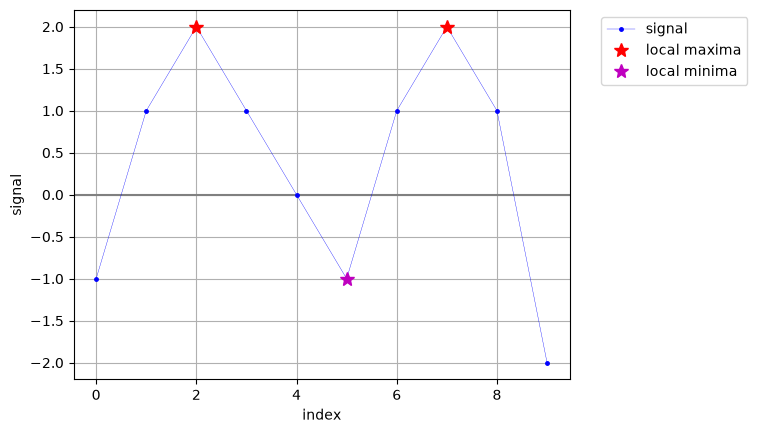

In [9]:
display_signal_and_extrema(index, signal)

## Section 3 - Analyze a known signal

### 3.1. Create the signal and plot it

A framework for generating and visualizing synthetic time-series signals is provided here. 

1. generate_time = A discrete time vector is generated based on a specified sampling frequency and duration, avoiding floating-point rounding errors. 

2. generate_sine = Sine waves are synthesized with customizable amplitude, frequency, and phase shift. 
    The following equation is used to create sine waves - 
        $$s(t) = A \cdot \sin(2\pi f t + \phi)$$

3. display_signals = The individual signal components alongside their combined summation are plotted against time, formatted with customized marker sizes, a reference zero line, a grid, and an external legend.

In [10]:
def generate_time(duration: float, fs: float):
    """Generate the time axis for a sampled signal.

    Parameters
    ----------
    duration : float
        Length of the signal in seconds. The end time itself is excluded.
    fs : float
        Sampling frequency in Hz (samples per second).

    Returns
    -------
    np.ndarray
        1D array of time stamps in seconds: 0, 1/fs, 2/fs, ...
        with int(duration * fs) samples.
    """
    # Build integer sample numbers first and divide by fs. This avoids the
    # rounding errors of np.arange with a float step such as 0.01.
    return np.arange(int(round(duration * fs))) / fs


def generate_sine(t: np.ndarray, amplitude: float, frequency: float, phase: float = 0.0):
    """Generate a sine wave: amplitude * sin(2*pi*frequency*t + phase).

    Parameters
    ----------
    t : np.ndarray
        1D array of time stamps in seconds.
    amplitude : float
        Peak value of the wave.
    frequency : float
        Frequency in Hz (number of full cycles per second).
    phase : float, optional
        Phase shift in radians (default 0). A positive phase shifts the
        wave to the left, so it starts "ahead" in its cycle.

    Returns
    -------
    np.ndarray
        1D array of wave values, same length as `t`.
    """
    # 2*pi*frequency converts cycles per second into radians per second
    return amplitude * np.sin(2 * np.pi * frequency * t + phase)


def display_signals(t: np.ndarray, s1: np.ndarray, s2: np.ndarray, s: np.ndarray):
    """Plot two component signals and their sum against time in a new figure.

    Parameters
    ----------
    t : np.ndarray
        1D array of time stamps in seconds.
    s1, s2 : np.ndarray
        The two component signals, same length as `t`.
    s : np.ndarray
        The combined signal, same length as `t`.

    Returns
    -------
    None
    """
    plt.figure()
    # Gray zero line first so it stays behind the signals
    plt.axhline(y=0, color="gray", linestyle="-")
    # Components get small markers, the combined signal larger ones
    plt.plot(t, s1, ".-", color="green", markersize=3, linewidth=0.25, label="s1")
    plt.plot(t, s2, ".-", color="orange", markersize=3, linewidth=0.25, label="s2")
    plt.plot(t, s, ".-", color="blue", markersize=8, linewidth=0.25, label="s")
    plt.xlabel("time [s]")
    plt.ylabel("signal")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()

The follwoing parameters are used to create the sine waves

| Signal / Variable | Amplitude ($A$) | Frequency ($f$) | Phase ($\phi$) | Description / Equation |
| :--- | :--- | :--- | :--- | :--- |
| **`t`** | — | — | — | Time vector ($0 \text{ to } 1.99\text{ s}$, $200\text{ samples}$ at $f_s = 100\text{ Hz}$) |
| **`s1`** | $1$ | $2\text{ Hz}$ | $0\text{ rad}$ ($0^\circ$) | $s_1(t) = 1 \cdot \sin(2\pi \cdot 2 \cdot t)$ |
| **`s2`** | $2$ | $1\text{ Hz}$ | $\frac{\pi}{3}\text{ rad}$ ($60^\circ$) | $s_2(t) = 2 \cdot \sin\left(2\pi \cdot 1 \cdot t + \frac{\pi}{3}\right)$ |
| **`s`** | — | — | — | Combined signal: $s(t) = s_1(t) + s_2(t)$ |

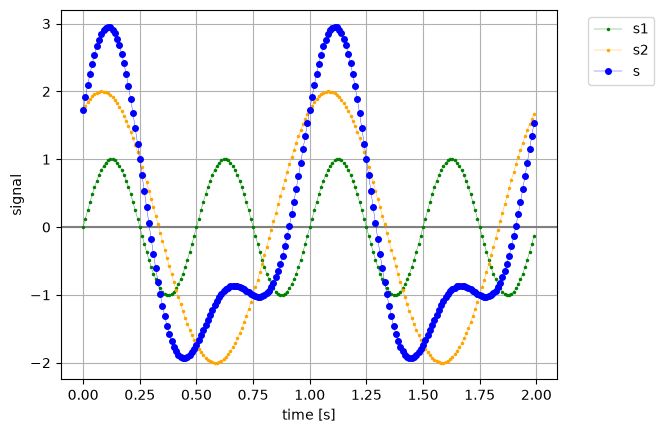

In [11]:
t = generate_time(duration=2, fs=100)                       # 0 to 1.99 s, 200 samples
s1 = generate_sine(t, amplitude=1, frequency=2)             # 2 Hz, no phase shift
s2 = generate_sine(t, amplitude=2, frequency=1, phase=np.pi / 3)   # 1 Hz, shifted by 60°
s = s1 + s2                                                 # combined signal

display_signals(t, s1, s2, s)

### 3.2. Plot the remarkable points

A complete visualization workflow for displaying a signal alongside its critical feature points is presented here. 

First, the main signal curve is plotted on a new figure with a customizable x-axis label. Next, zero crossings (marked as triangles) as well as local maxima and minima (marked as stars) are overlaid onto the same axes. Finally, the figure is rendered with an external legend, grid lines, and displayed to illustrate the feature locations relative to the overall waveform.

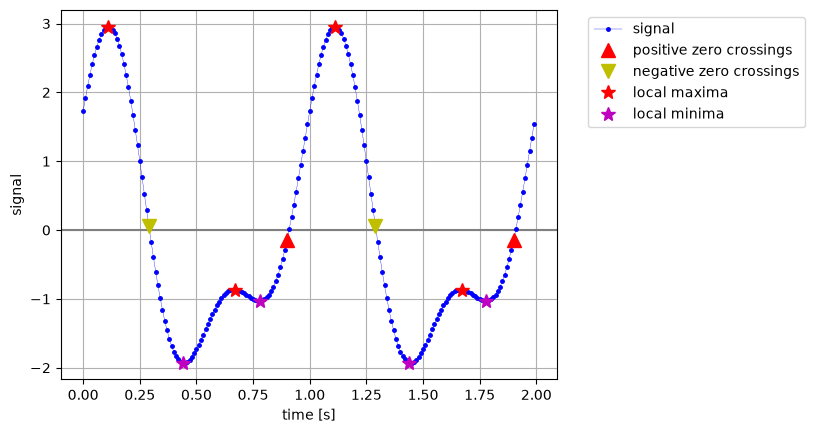

In [16]:

def display_signal_crossings_and_extrema(i: np.ndarray, s: np.ndarray, xlabel: str = "index"):
    """Create a new figure showing a signal with its zero crossings and extrema.

    Plots the signal, marks positive and negative zero crossings (triangles)
    and local maxima and minima (stars) on the same axes, adds a legend
    outside the axes and a grid, then displays the figure.

    Parameters
    ----------
    i : np.ndarray
        1D array of x-values (indices or times) of the signal.
    s : np.ndarray
        1D array of signal values, same length as `i`.
    xlabel : str, optional
        Label of the x-axis (default "index"; use e.g. "time [s]" for a
        signal sampled in time).

    Returns
    -------
    None
    """
    plt.figure()
    plot_signal(i, s)
    # Overwrite the default "index" label set by plot_signal
    plt.xlabel(xlabel)
    # All of these draw on the current figure, so they end up on the same plot
    plot_zero_crossings(i, s)
    plot_local_maxima(i, s)
    plot_local_minima(i, s)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.show()


display_signal_crossings_and_extrema(t, s, xlabel="time [s]")

### 3.3. Use the remarkable points to find the frequency of the signal

In [17]:
def compute_frequency_from_zero_crossings(t: np.ndarray, s: np.ndarray):
    """Estimate the frequency of a periodic signal from its zero crossings.

    Zero crossings with the same slope (all positive ones, or all negative
    ones) are exactly one period apart. The spacing between consecutive
    positive crossings, and between consecutive negative crossings, gives
    two estimates of the period, which are averaged.

    Parameters
    ----------
    t : np.ndarray
        1D array of time stamps in seconds, uniformly spaced.
    s : np.ndarray
        1D array of signal values, same length as `t`.

    Returns
    -------
    dict
        delta_zero_crossing_pos : np.ndarray
            Distances in samples between consecutive positive crossings.
        delta_zero_crossing_neg : np.ndarray
            Distances in samples between consecutive negative crossings.
        signal_period_pos : float
            Period in seconds estimated from the positive crossings.
        signal_period_neg : float
            Period in seconds estimated from the negative crossings.
        signal_period : float
            Average of the two period estimates, in seconds.
        signal_frequency : float
            Frequency in Hz (1 / signal_period).
        Period and frequency values are NaN if the signal has fewer than
        two crossings of the corresponding slope (no period can be measured).
    """
    t = np.asarray(t)
    s = np.asarray(s)

    # Indices of crossings with the same slope: positive ones (- -> +)
    # and negative ones (+ -> -)
    i_pos, i_neg = find_zero_crossings(s)

    # Distance in samples between consecutive crossings of the same slope.
    # With N crossings, np.diff gives N - 1 distances (empty if N < 2).
    delta_pos = np.diff(i_pos)
    delta_neg = np.diff(i_neg)

    # Time between two samples (assumes uniform sampling)
    dt = t[1] - t[0]

    # Period = average distance in samples * time per sample.
    # Without at least two crossings there is nothing to average -> NaN.
    period_pos = np.mean(delta_pos) * dt if delta_pos.size > 0 else np.nan
    period_neg = np.mean(delta_neg) * dt if delta_neg.size > 0 else np.nan

    # Combine both estimates; nanmean ignores one that is missing, but if
    # both are missing the period (and frequency) stay NaN.
    if np.isnan(period_pos) and np.isnan(period_neg):
        period = np.nan
    else:
        period = np.nanmean([period_pos, period_neg])

    # Frequency is the inverse of the period (NaN stays NaN)
    frequency = 1 / period

    return {
        "delta_zero_crossing_pos": delta_pos,
        "delta_zero_crossing_neg": delta_neg,
        "signal_period_pos": period_pos,
        "signal_period_neg": period_neg,
        "signal_period": period,
        "signal_frequency": frequency,
    }


def print_frequency_info(info: dict):
    """Print the dictionary from `compute_frequency_from_zero_crossings`.

    Prints one line per entry, with the units added and the names
    right-aligned so that the colons line up.

    Parameters
    ----------
    info : dict
        Output of `compute_frequency_from_zero_crossings`.

    Returns
    -------
    None
    """
    # Units shown next to each key
    units = {
        "delta_zero_crossing_pos": "samples",
        "delta_zero_crossing_neg": "samples",
        "signal_period_pos": "s",
        "signal_period_neg": "s",
        "signal_period": "s",
        "signal_frequency": "Hz",
    }
    labels = {key: f"{key} ({units[key]})" for key in info}
    width = max(len(label) for label in labels.values())
    for key, value in info.items():
        print(f"{labels[key]:>{width}} : {value}")

In [19]:
info = compute_frequency_from_zero_crossings(t, s)
print_frequency_info(info)

delta_zero_crossing_pos (samples) : [100]
delta_zero_crossing_neg (samples) : [100]
            signal_period_pos (s) : 1.0
            signal_period_neg (s) : 1.0
                signal_period (s) : 1.0
            signal_frequency (Hz) : 1.0
